In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel


In [2]:
simulations = [np.load(f"simulations/sample_{i:06d}.npz",
                       allow_pickle=True) for i in range(2500)]

k = simulations[0]["k"]
powers = np.array([sim["power"] for sim in simulations])
astro_params = np.array([list(sim["astro_params"].item().values()) 
                         for sim in simulations])
cosmo_params = np.array([list(sim["cosmo_params"].item().values()) 
                         for sim in simulations])
param_names = list(simulations[0]["astro_params"].item().keys()) + \
              list(simulations[0]["cosmo_params"].item().keys())

X = np.hstack([astro_params, cosmo_params])
X[:, 0] = np.log10(X[:, 0])  # log-transform the first parameter (e.g., M_min)
X[:, 1:] = np.log10(X[:, 1:])  # log-transform the other parameters
X.shape

(2500, 4)

Number of components to retain 99.99% variance: 3


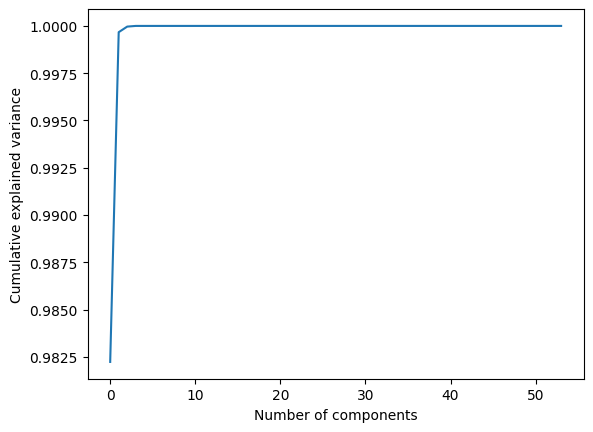

In [3]:
from sklearn.model_selection import train_test_split

train_powers, test_powers, train_X, test_X = train_test_split(powers, X, test_size=0.2)

cov = np.cov(train_powers.T)

eigenvalues, eigenvectors = np.linalg.eig(cov)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca-variance.png', dpi=300, bbox_inches='tight')

n_components = np.where(cumulative_variance >= 0.9999)[0][0] + 1
print(f'Number of components to retain 99.99% variance: {n_components}')

# project the data onto the top n_components eigenvectors
train_pca = train_powers @ eigenvectors[:, :n_components]
test_pca = test_powers @ eigenvectors[:, :n_components]

norm_mean = np.mean(train_pca, axis=0)
norm_std = np.std(train_pca, axis=0)

train_pca = (train_pca - norm_mean) / norm_std
test_pca = (test_pca - norm_mean) / norm_std


In [4]:
kernel = ConstantKernel(1.0) * RBF(length_scale=[1.0]*4) 

gps = []
for i in range(n_components):
    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=5,
        random_state=i,
    )
    gp.fit(train_X, train_pca[:, i])
    gps.append(gp)
    print(f"GP {i+1} trained | log-marginal-likelihood = {gp.log_marginal_likelihood_value_:.2f}")



/Users/harrybevins/Documents/Talks/env/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GP 1 trained | log-marginal-likelihood = 9927.23
GP 2 trained | log-marginal-likelihood = 8996.54
GP 3 trained | log-marginal-likelihood = 8306.11


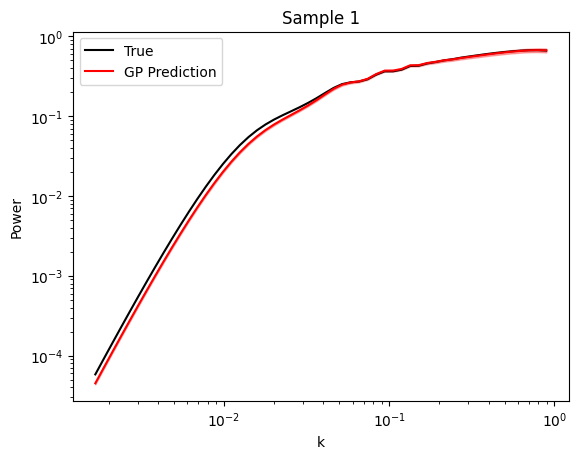

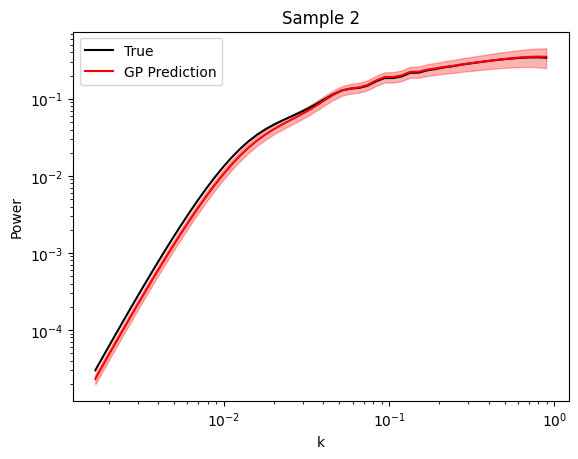

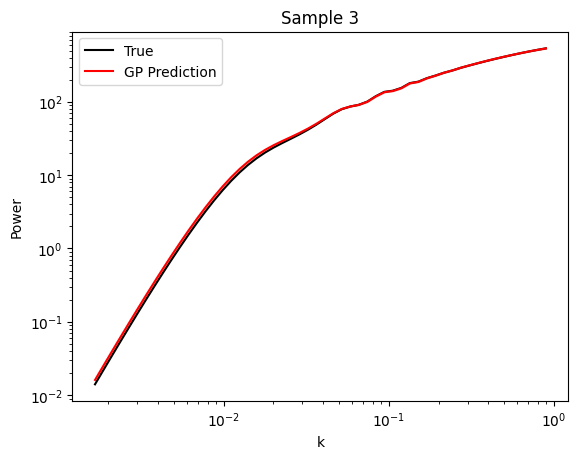

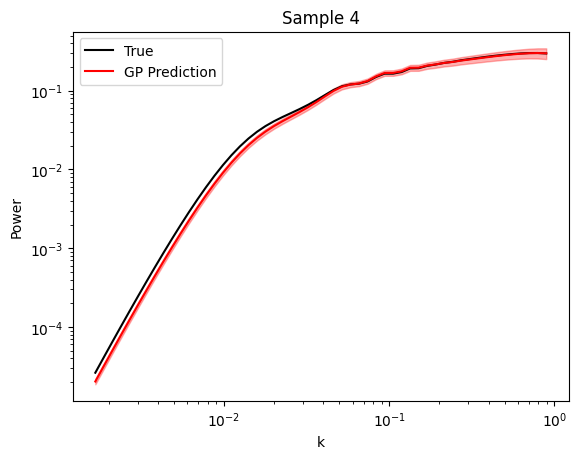

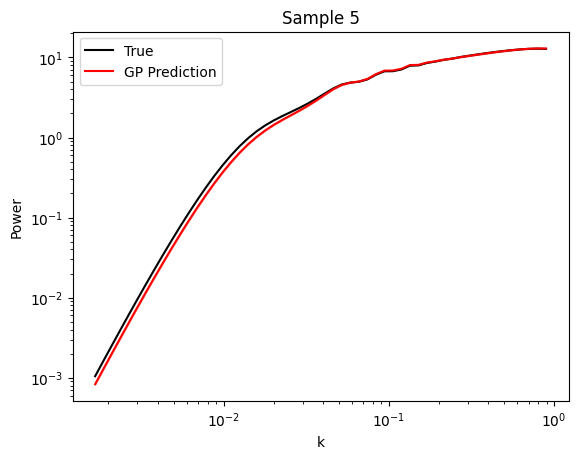

In [5]:
def predict(gps, X):
    n_samples = X.shape[0]
    n_components = len(gps)
    mean = np.zeros((n_samples, n_components))
    std = np.zeros((n_samples, n_components))
    
    for i, gp in enumerate(gps):
        mean[:, i], std[:, i] = gp.predict(X, return_std=True)
    
    return mean, std

test_mean, test_std = predict(gps, test_X)
test_mean = test_mean * norm_std + norm_mean
test_std = test_std * norm_std

reconstructed_mean = test_mean @ eigenvectors[:, :n_components].T 
reconstruction_std = np.sqrt(test_std**2 @ eigenvectors[:, :n_components].T**2)

for i in range(5):
    plt.plot(k, test_powers[i], label='True', color='k')
    plt.plot(k, reconstructed_mean[i], label='GP Prediction', color='r')
    plt.fill_between(k, reconstructed_mean[i] - reconstruction_std[i], 
                     reconstructed_mean[i] + reconstruction_std[i], color='r', alpha=0.3)
    plt.xlabel('k')
    plt.ylabel('Power')
    plt.loglog()
    plt.legend()
    plt.title(f'Sample {i+1}')
    plt.savefig(f'gp_prediction_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

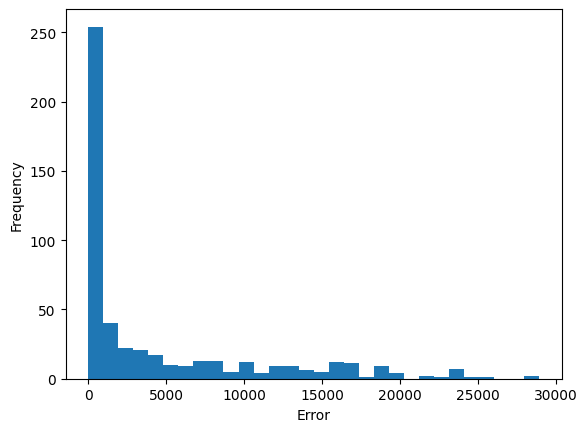

In [6]:
errors = [np.sum(np.abs(test_powers[i] - reconstructed_mean[i]) / np.abs(reconstruction_std[i])) for i in range(len(test_powers))]
errors = np.array(errors)

plt.hist(errors, bins=30)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.savefig('error_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

(30, 30, 3)

Saved figure to gp_emulator.png


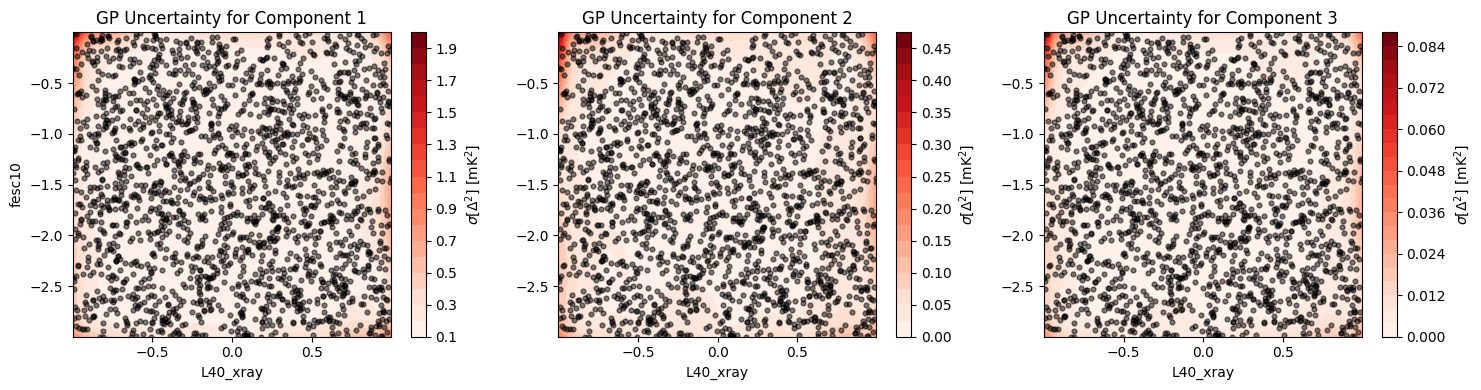

In [ ]:
n_grid   = 30
P1_grid  = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
P2_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
P3_grid = np.linspace(X[:, 2].min(), X[:, 2].max(), n_grid)
P4_grid = np.linspace(X[:, 3].min(), X[:, 3].max(), n_grid)
P1, P2 = np.meshgrid(P1_grid, P2_grid)

sigma_map = np.zeros((n_grid, n_grid, n_components))
for i in range(n_grid):
    for j in range(n_grid):
        mean, std = predict(gps, np.array([[P1[i,j], P2[i,j], P3_grid[n_grid//2], P4_grid[n_grid//2]]]))
        std = std * norm_std 
        sigma_map[i, j, :] = std

print(sigma_map.shape)
fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 4))

for i in range(n_components):
    ax = axes[i]
    im = ax.contourf(P1, P2, sigma_map[:, :, i], levels=20, cmap="Reds")
    plt.colorbar(im, ax=ax, label=r"$\sigma[\Delta^2]$ [mK$^2$]")
    if i == 0:
        ax.set_ylabel(param_names[1])
    ax.set_xlabel(param_names[0])

    # Overlay training points
    ax.scatter(train_X[:,0], train_X[:,1],
            s=12, c="k", alpha=0.5, zorder=5, label="Training points")
    ax.set_title(f"GP Uncertainty for Component {i+1}")

plt.tight_layout()
plt.savefig("gp_emulator_map_error.png", dpi=150, bbox_inches="tight")
print("\nSaved figure to gp_emulator.png")

[[-0.03503549 -1.4524869  -1.510884   -0.1325111 ]]
Grid shape: (900, 4)
(900, 1)
(900, 1)
(900, 1)


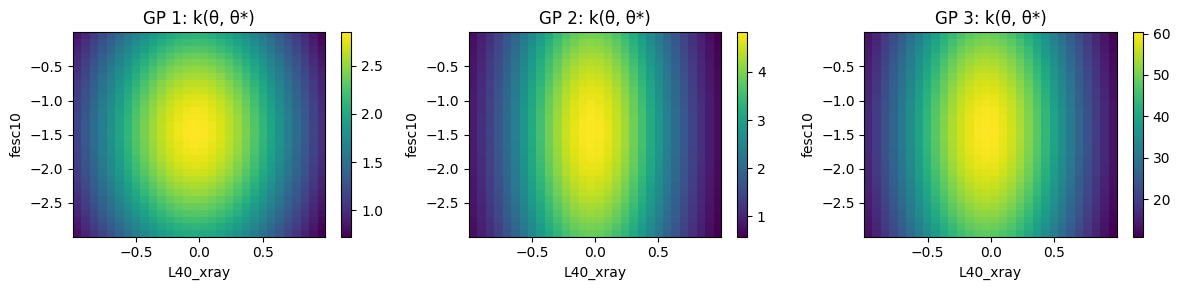

In [10]:
theta_ref = test_X.mean(axis=0).reshape(1, -1)  # centre of grid
print(theta_ref)

fig, axes = plt.subplots(1, len(gps), figsize=(4*len(gps), 3))

grid = np.column_stack([
    P1.ravel(),                          # (n_pts,)
    P2.ravel(),                          # (n_pts,)
    theta_ref[0, 2]*np.ones_like(P1.ravel()),     # (n_pts,)
    theta_ref[0, 3]*np.ones_like(P1.ravel())      # (n_pts,)
])  # shape (n_pts, 4) ✓


print("Grid shape:", grid.shape)
for i, gp in enumerate(gps):
    K = gp.kernel_(grid, theta_ref)
    print(K.shape)
    im = axes[i].imshow(K.reshape(n_grid, n_grid), 
                        cmap='viridis', aspect='auto',
                        origin='lower',
                        extent=(P1_grid.min(), P1_grid.max(), P2_grid.min(), P2_grid.max()))
    axes[i].set_xlabel(param_names[0])
    axes[i].set_ylabel(param_names[1])
    axes[i].set_title(f'GP {i+1}: k(θ, θ*)')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()

GP 1: {'k1': 1.69**2, 'k2': RBF(length_scale=[0.72, 1.87, 0.52, 435]), 'k1__constant_value': np.float64(2.8472080660401833), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.72026042,   1.86938677,   0.52026547, 435.43556295]), 'k2__length_scale_bounds': (1e-05, 100000.0)}
GP 2: {'k1': 2.2**2, 'k2': RBF(length_scale=[0.53, 2.3, 0.383, 136]), 'k1__constant_value': np.float64(4.82303841532095), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.52959234,   2.30319595,   0.38310354, 135.53518868]), 'k2__length_scale_bounds': (1e-05, 100000.0)}
GP 3: {'k1': 7.76**2, 'k2': RBF(length_scale=[0.6, 2.29, 0.405, 365]), 'k1__constant_value': np.float64(60.291891780141704), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.60031871,   2.29190609,   0.40533126, 364.60923444]), 'k2__length_scale_bounds': (1e-05, 100000.0)}


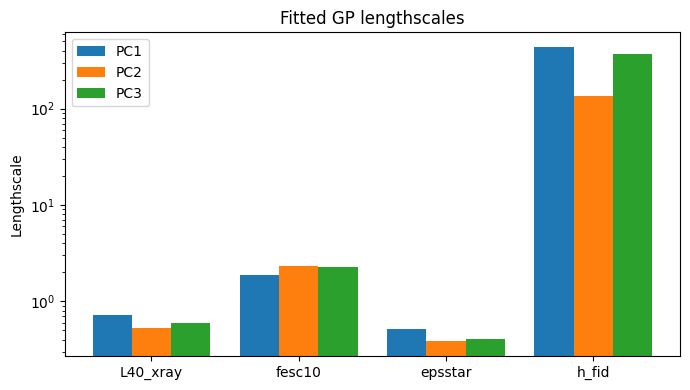

In [12]:
for i, gp in enumerate(gps):
    ls = gp.kernel_.get_params()
    print(f"GP {i+1}: {ls}")

lengthscales = np.array([
    gp.kernel_.get_params()['k2__length_scale']
    for gp in gps
])  # shape (n_components, n_params)

n_params = lengthscales.shape[1]
x = np.arange(n_params)
width = 0.8 / len(gps)

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(gps)):
    ax.bar(x + i*width, lengthscales[i], width, label=f'PC{i+1}')

ax.set_xticks(x + width*(len(gps)-1)/2)
ax.set_xticklabels(param_names)
ax.set_ylabel('Lengthscale')
ax.set_yscale('log')   # log scale essential given the 414 outlier
ax.set_title('Fitted GP lengthscales')
ax.legend()
plt.tight_layout()